In [ ]:
pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
trades = pd.read_csv("historical_data.csv")

print("Shape:", trades.shape)
print("\nColumns:")
print(trades.columns)

trades.head()

Shape: (211224, 16)

Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment = pd.read_csv("fear_greed_index.csv")

print("Shape:", sentiment.shape)
print("\nColumns:")
print(sentiment.columns)

sentiment.head()

Shape: (2644, 4)

Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print("Trader Dataset Missing Values:")
print(trades.isnull().sum())

print("\nSentiment Dataset Missing Values:")
print(sentiment.isnull().sum())

Trader Dataset Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Dataset Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
).dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

print("Date Conversion Completed")

Date Conversion Completed


In [ ]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [ ]:
print(
    merged['classification']
    .value_counts()
)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [ ]:
total_profit = merged.groupby(
    'classification'
)['Closed PnL'].sum()

print(total_profit)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [ ]:
avg_profit = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(avg_profit)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [ ]:
trade_count = merged.groupby(
    'classification'
).size()

print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


In [ ]:
volume = merged.groupby(
    'classification'
)['Size USD'].sum()

print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


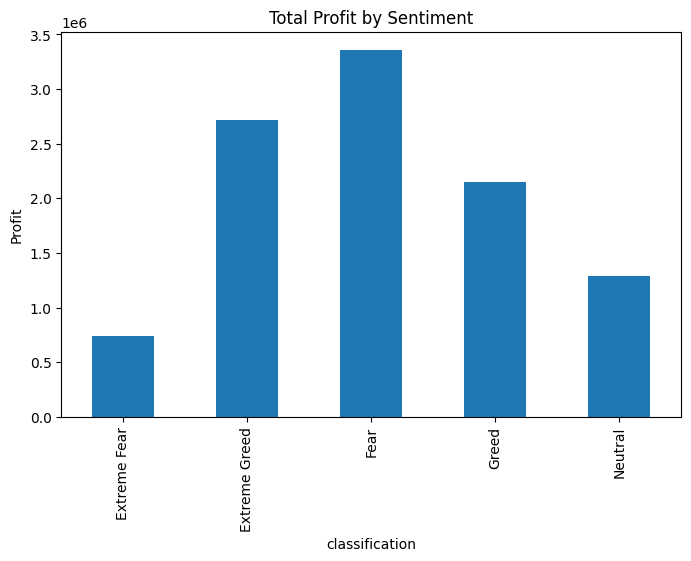

In [ ]:
plt.figure(figsize=(8,5))

total_profit.plot(kind='bar')

plt.title("Total Profit by Sentiment")
plt.ylabel("Profit")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

avg_profit.plot(kind='bar')

plt.title("Average Profit by Sentiment")
plt.ylabel("Average PnL")

plt.show()

In [ ]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
)

print(top_traders.head(10))

In [ ]:
buy_sell = merged.groupby(
    ['classification','Side']
)['Closed PnL'].mean()

print(buy_sell)

In [ ]:
summary = merged.groupby(
    'classification'
).agg({
    'Closed PnL':['sum','mean'],
    'Size USD':'sum'
})

summary.to_csv(
    'sentiment_analysis_results.csv'
)

print("Results Saved Successfully")

In [ ]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['Win'].mean() * 100

print(win_rate)

In [ ]:
correlation = merged[
    ['Closed PnL','value']
].corr()

print(correlation)